# Notebook 06b: SHAP Interrogation and Robustness Checks
# Purpose: Test for experimental bias and multicollinearity in the ML thermobarometer.

--- SETUP ---

In [1]:
%matplotlib inline
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from config import (ROOT, DATA_RAW, DATA_PROC, DATA_SPLITS, DATA_NATURAL,
                    MODELS, FIGURES, RESULTS, LOGS, EXPETDB)

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.rcParams.update({'font.sans-serif': ['Arial'], 'font.size': 10})

# Load the data using config paths
df = pd.read_csv(DATA_PROC / 'opx_clean_core.csv')
print(f"Loaded core dataset: {len(df)} rows\n")
# Keep df_liq for backwards compatibility with this notebook
df_liq = df.copy()
# Targets
y_P = df_liq['P_kbar']
y_T = df_liq['T_C']
# Create expected 'liq_' aliases if original names differ
if 'liq_SiO2' not in df_liq.columns and 'SiO2' in df_liq.columns:
    df_liq['liq_SiO2'] = df_liq['SiO2']
if 'liq_MgO' not in df_liq.columns and 'MgO' in df_liq.columns:
    df_liq['liq_MgO'] = df_liq['MgO']
if 'Ca' not in df_liq.columns and 'CaO' in df_liq.columns:
    df_liq['Ca'] = df_liq['CaO']
# Select numeric features only for X (drop the target columns) and impute numeric NaNs
X = df_liq.select_dtypes(include=[np.number]).drop(columns=['P_kbar', 'T_C']).fillna(df_liq.select_dtypes(include=[np.number]).mean())


Loaded core dataset: 1148 rows



In [2]:
# Recreate the exact train/test split from Notebook 03 to ensure consistency
from sklearn.model_selection import train_test_split
X_train, X_test, y_train_P, y_test_P, y_train_T, y_test_T = train_test_split(
    X, y_P, y_T, test_size=0.2, random_state=42 # Add stratification if used in nb03
)

# Load the best hyperparameters found in Notebook 03
# Replace these with your actual best_params dictionaries
best_params_P = {'n_estimators': 500, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'} 
best_params_T = {'n_estimators': 500, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}

# Calculate baseline RMSE for comparison
model_base_P = RandomForestRegressor(**best_params_P, random_state=42, n_jobs=-1)
model_base_P.fit(X_train, y_train_P)
original_rmse_P = np.sqrt(mean_squared_error(y_test_P, model_base_P.predict(X_test)))

model_base_T = RandomForestRegressor(**best_params_T, random_state=42, n_jobs=-1)
model_base_T.fit(X_train, y_train_T)
original_rmse_T = np.sqrt(mean_squared_error(y_test_T, model_base_T.predict(X_test)))


--- TEST 1: THE ABLATION TEST ---

In [3]:
print("--- TEST 1: ABLATION TEST ---")
suspect_features = ['liq_SiO2', 'liq_MgO']

# Drop features
X_train_ab = X_train.drop(columns=suspect_features)
X_test_ab = X_test.drop(columns=suspect_features)

# Retrain Pressure Model
model_ab_P = RandomForestRegressor(**best_params_P, random_state=42, n_jobs=-1)
model_ab_P.fit(X_train_ab, y_train_P)
rmse_ab_P = np.sqrt(mean_squared_error(y_test_P, model_ab_P.predict(X_test_ab)))

# Retrain Temperature Model
model_ab_T = RandomForestRegressor(**best_params_T, random_state=42, n_jobs=-1)
model_ab_T.fit(X_train_ab, y_train_T)
rmse_ab_T = np.sqrt(mean_squared_error(y_test_T, model_ab_T.predict(X_test_ab)))

print(f"Original P RMSE: {original_rmse_P:.3f} kbar")
print(f"Ablated P RMSE:  {rmse_ab_P:.3f} kbar")
print(f"Difference:      {rmse_ab_P - original_rmse_P:.3f} kbar\n")

print(f"Original T RMSE: {original_rmse_T:.2f} °C")
print(f"Ablated T RMSE:  {rmse_ab_T:.2f} °C")
print(f"Difference:      {rmse_ab_T - original_rmse_T:.2f} °C")


--- TEST 1: ABLATION TEST ---


Original P RMSE: 10.365 kbar
Ablated P RMSE:  10.233 kbar
Difference:      -0.132 kbar

Original T RMSE: 137.92 °C
Ablated T RMSE:  137.31 °C
Difference:      -0.61 °C


--- TEST 2: EXPERIMENTAL DESIGN PROXY CHECK ---

--- TEST 2: PROXY CHECK PLOTS ---


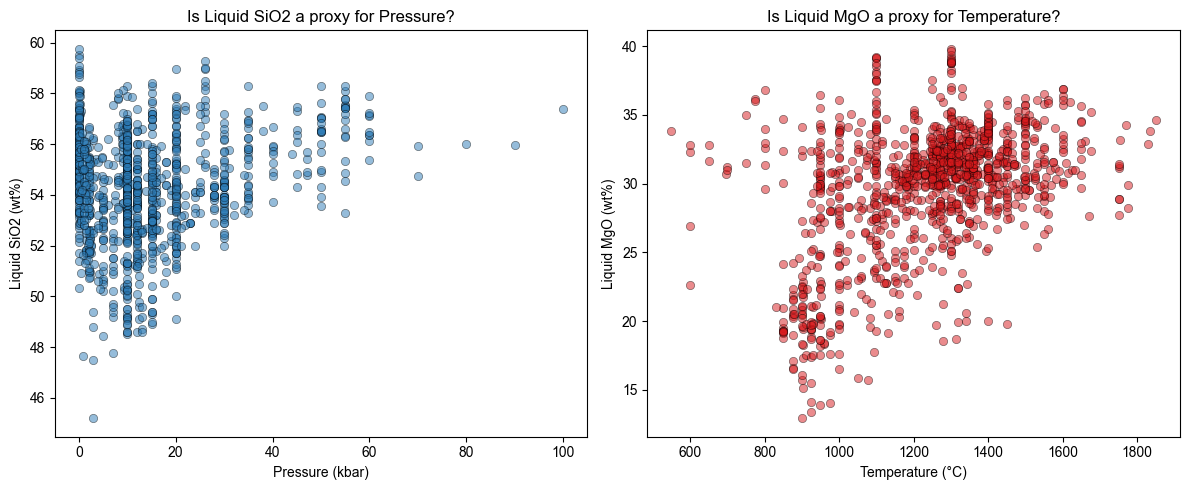

In [4]:
print("--- TEST 2: PROXY CHECK PLOTS ---")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Liquid SiO2 vs Pressure
axes[0].scatter(df_liq['P_kbar'], df_liq['liq_SiO2'], alpha=0.5, c='#2c7bb6', edgecolor='k', linewidth=0.5)
axes[0].set_xlabel('Pressure (kbar)')
axes[0].set_ylabel('Liquid SiO2 (wt%)')
axes[0].set_title('Is Liquid SiO2 a proxy for Pressure?')

# Plot Liquid MgO vs Temperature
axes[1].scatter(df_liq['T_C'], df_liq['liq_MgO'], alpha=0.5, c='#d7191c', edgecolor='k', linewidth=0.5)
axes[1].set_xlabel('Temperature (°C)')
axes[1].set_ylabel('Liquid MgO (wt%)')
axes[1].set_title('Is Liquid MgO a proxy for Temperature?')

plt.tight_layout()
plt.savefig('fig_06b_proxy_check.png', dpi=300)
plt.show()


--- TEST 3: FEATURE CORRELATION CHECK ---

--- TEST 3: FEATURE CORRELATION HEATMAP ---


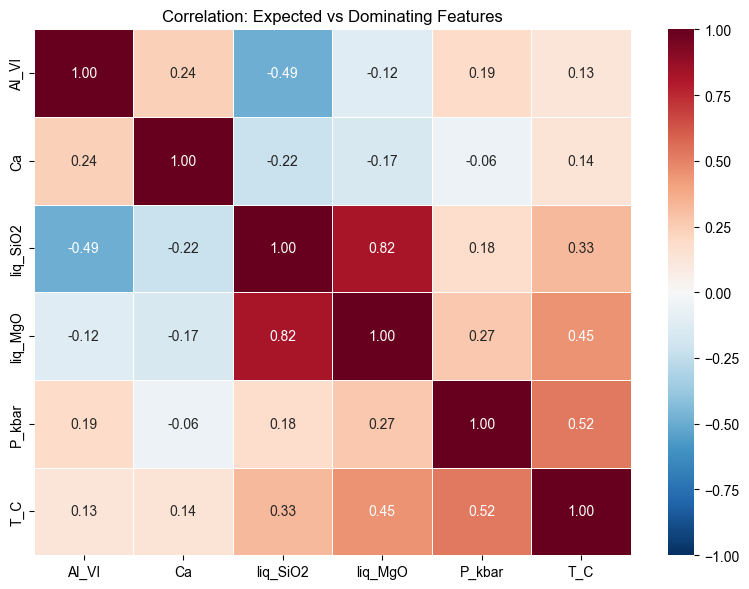

In [5]:
print("--- TEST 3: FEATURE CORRELATION HEATMAP ---")
# Adjust 'Al_VI' and 'Ca' to match your exact column names if different (e.g., 'Al2O3', 'CaO')
check_cols = ['Al_VI', 'Ca', 'liq_SiO2', 'liq_MgO', 'P_kbar', 'T_C'] 

# Ensure all columns exist before running correlation
missing_cols = [c for c in check_cols if c not in df_liq.columns]
if missing_cols:
    print(f"Warning: Columns {missing_cols} not found. Check your dataframe column names.")
else:
    corr_matrix = df_liq[check_cols].corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
    plt.title("Correlation: Expected vs Dominating Features")
    plt.tight_layout()
    plt.savefig('fig_06b_correlation_check.png', dpi=300)
    plt.show()
